# seaborn

In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [2]:
fonts = ['Microsoft YaHei', 'SimHei', 'SimSun', 'sans-serif']

sns.set_theme(
    style="whitegrid", 
    context="notebook", 
    palette="muted",
    font=fonts,
    rc={
        "axes.unicode_minus": False,   # 解决负号乱码
        "lines.linewidth": 2.5         # 线条加粗，更有质感
    }
)
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

seaborn 接口返回值：
- ax: 表示单图，
- Grid: 表示多图。
- Figure：特例。聚类图不常见。
https://seaborn.pydata.org/tutorial.html

Axes(0.125,0.11;0.775x0.77)


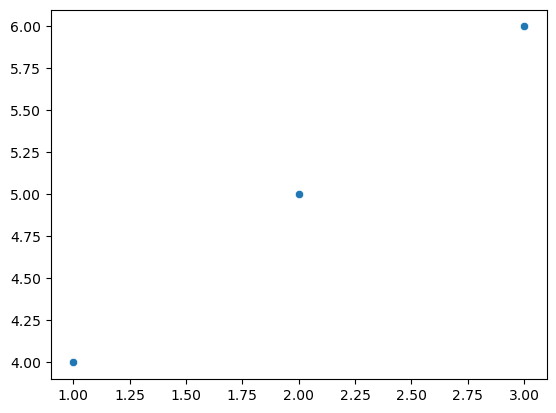

In [ ]:
import seaborn as sns

ax = sns.scatterplot(x=[1, 2, 3], y=[4, 5, 6])  # 返回 Axes
print(ax)  # <AxesSubplot: ...>  


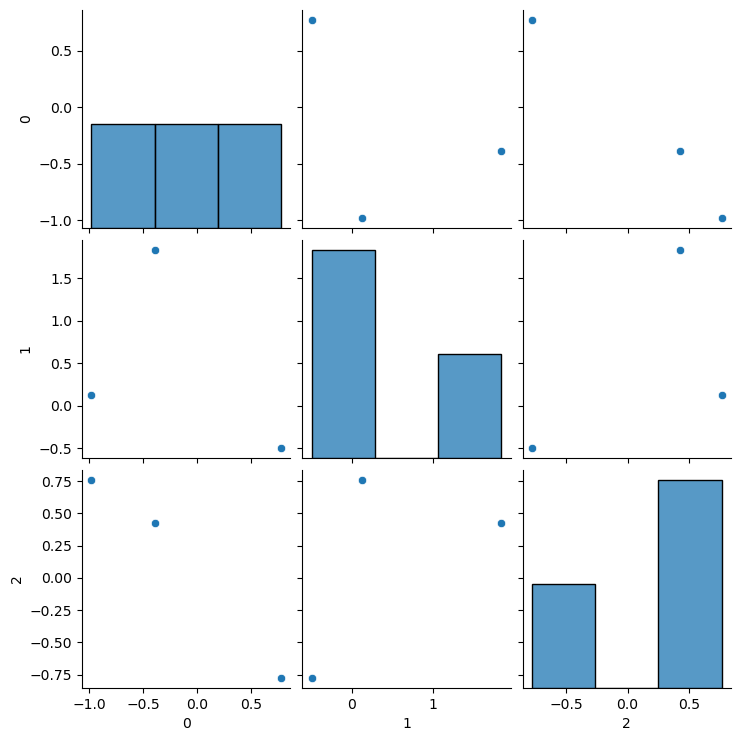

In [ ]:
import numpy as np
import pandas as pd
zz = np.random.randn(3,3)
df = pd.DataFrame(zz)
sns.pairplot(df)

## 4.16.1　Seaborn与Matplotlib
- 如果是ax-level接口,返回ax对象; 如histplot、scatterplt
- figure-level接口，返回网格对象，通过.figure, .axes获取; 如pairplot

In [ ]:
import matplotlib.pyplot as plt 
plt.style.use('classic') 
%matplotlib inline 
import numpy as np 
import pandas as pd


In [ ]:
# 创建一些数据 
rng = np.random.RandomState(0) 
x = np.linspace(0, 10, 500) 
y = np.cumsum(rng.randn(500, 6), 0) # 累积求和。  生成500*6矩阵，然后列聚合， 500*1

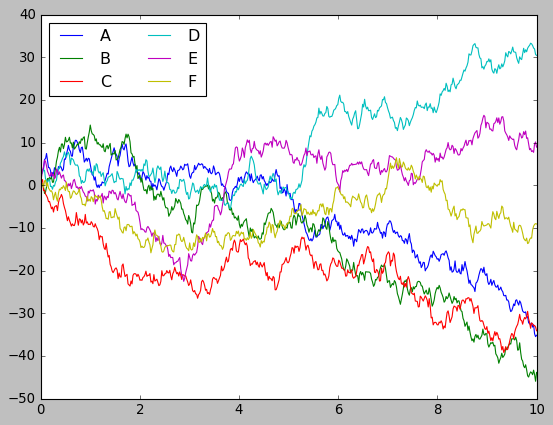

In [ ]:
# 用Matplotlib默认样式画图 
plt.plot(x, y) 
plt.legend('ABCDEF', ncol=2, loc='upper left');

In [ ]:
import seaborn as sns 
sns.set()

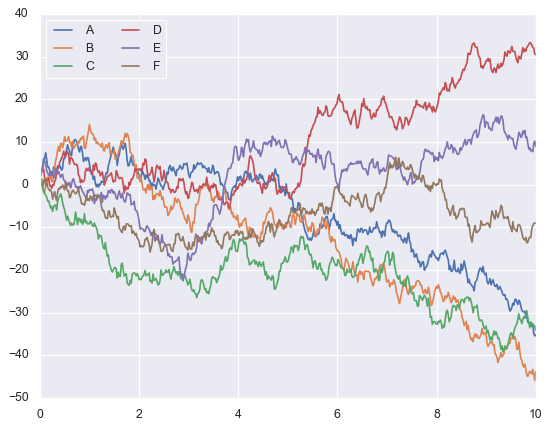

In [ ]:
# 同样的代码，seaborn绘图
plt.plot(x, y) 
plt.legend('ABCDEF', ncol=2, loc='upper left');

**更好看了seaborn**

默认很多时候出发legend

## 1. 频次直方图、KDE和密度图：数据分布


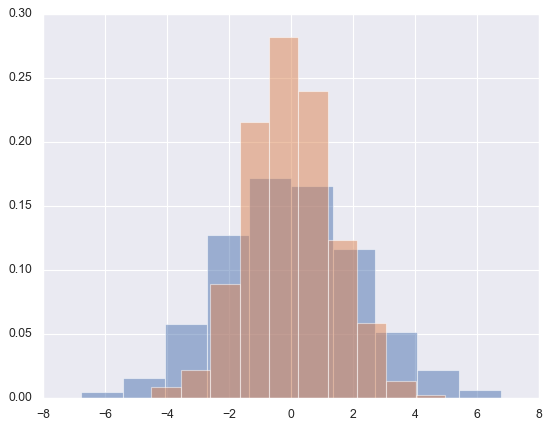

In [ ]:
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000) # 生成2000个二维正太分布点
data = pd.DataFrame(data, columns=['x', 'y']) 

for col in 'xy':  # 遍历xy列，  绘制x和y两个方向的hist
   plt.hist(data[col], density=True, alpha=0.5) # density=True 直方图面积和1

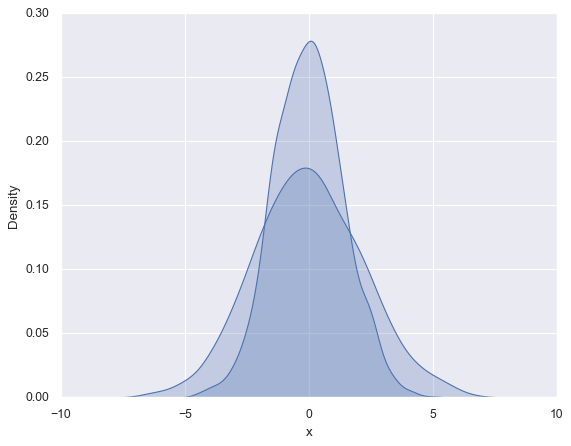

In [ ]:
for col in 'xy': 
    sns.kdeplot(data[col], fill=True) # KDE平滑图

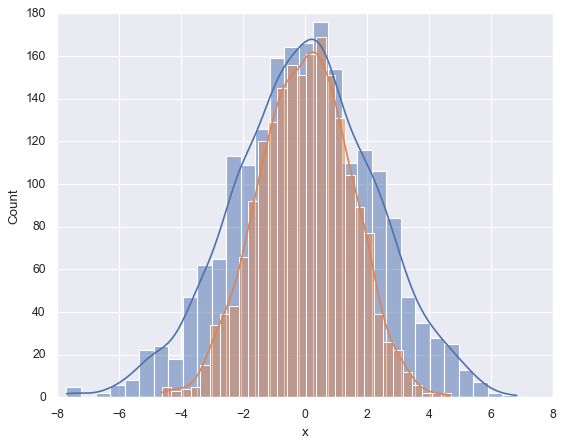

In [ ]:
sns.histplot (data['x'], kde=True) # 平滑图和直方图
sns.histplot (data['y'], kde=True);

二维图

<Axes: xlabel='x', ylabel='y'>

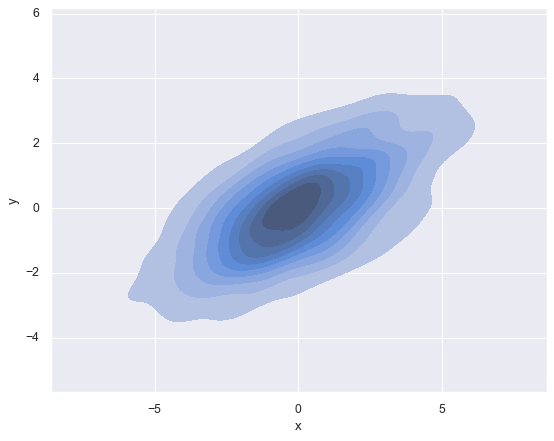

In [ ]:
sns.kdeplot(data=data, x='x', y='y', fill=True)

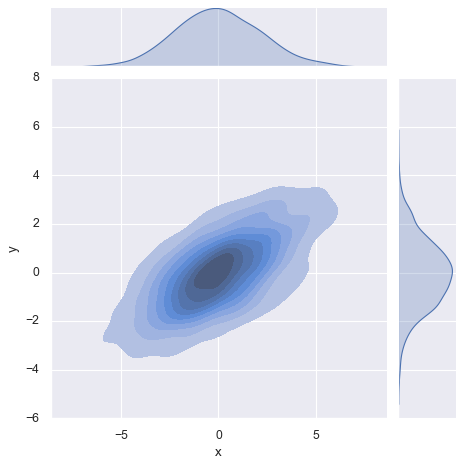

In [ ]:
# 使用 jointplot 绘制二维数据的关系，  会带有变量的分布
sns.jointplot(data=data, x='x', y='y', kind='kde', fill=True)

## 2. 矩阵图： 多组2变量关系
对多维数据可视化，常常需要所有两个变量的关系，探索不同维度之间的相关性。

In [ ]:
iris = sns.load_dataset("iris") 
iris.head() 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


sns.pairplot  
- kind: 图类型。 scatter默认。 'kde'平滑曲线
- diag_kind='kde':对角线上的图用KDE代替直方图hist
- hue : 按类别着色， 值为一个列名
- palette: 调色方案. 如'deep'
- height: 每个子图大小
- aspect: 长宽比

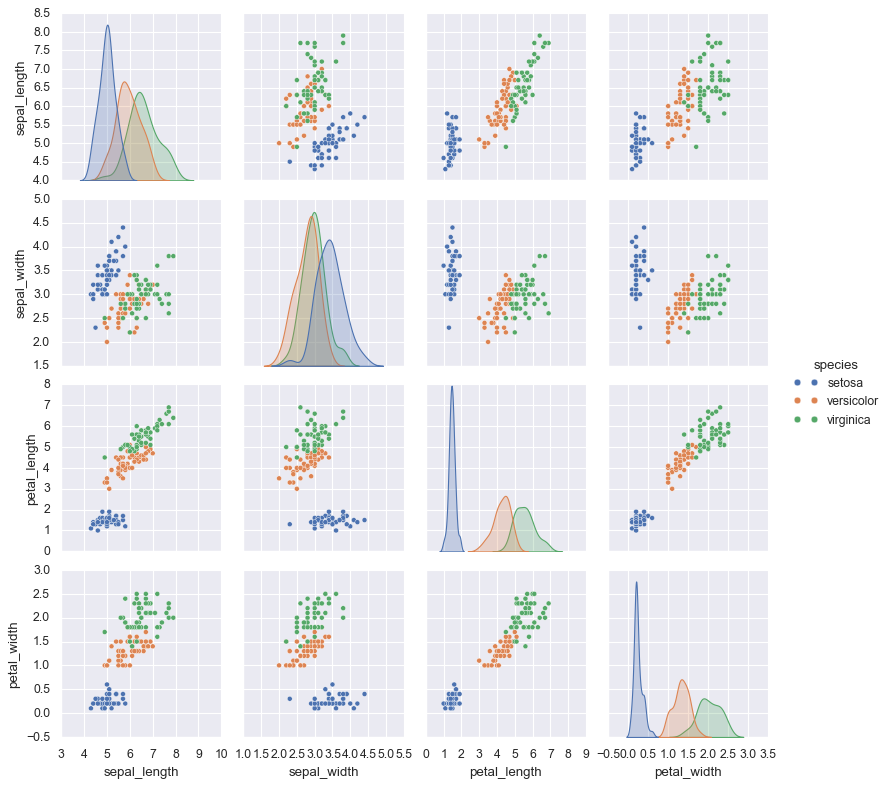

In [ ]:
sns.pairplot(iris, hue='species', height=2.5); # 直接一句代码即可

## 3. 分面频次直方图：按类别的直方图。 按类别分布

In [ ]:
tips = sns.load_dataset('tips') 
tips.head() 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


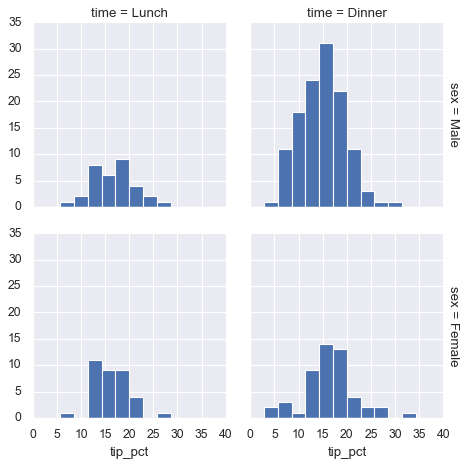

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill'] # 小费占总账单的百分比。
 
grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True) # 用于根据指定的分类变量来拆分数据，并生成一个 面板（facet） 图。
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15)); 

## 4. 箱线图： 分位点
- 箱体：Q1-Q3分位点. 四分位距`IQR = Q3 - Q1`
- 箱体里面横线：median
- 须：非异常范围。端点默认为`Q1 - 1.5 × IQR` 和 `Q3 + 1.5 × IQR`
- 单独点：异常值

箱线图 缺点 在于盒子里看不到样本的数量. 使用stripplot 分类散点

`catplot` : categorical

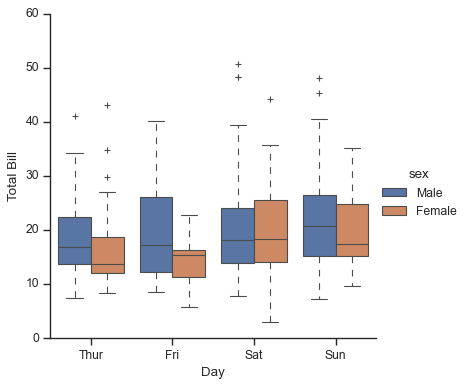

In [ ]:
with sns.axes_style(style='ticks'): 
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box") 
    g.set_axis_labels("Day", "Total Bill")

<Axes: xlabel='class', ylabel='age'>

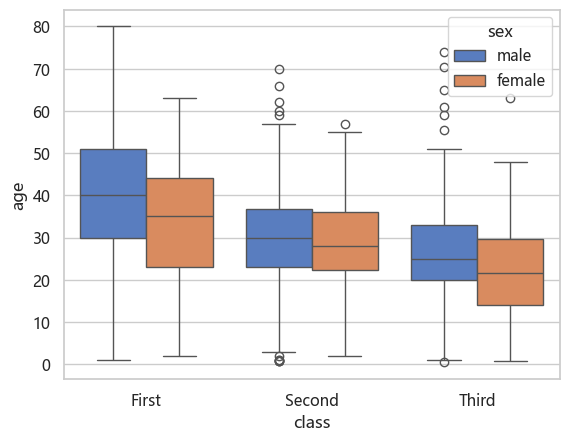

In [6]:
titanic = sns.load_dataset('titanic')
sns.boxplot(data=titanic, x = 'class', y='age', hue='sex')

## 5. 联合分布

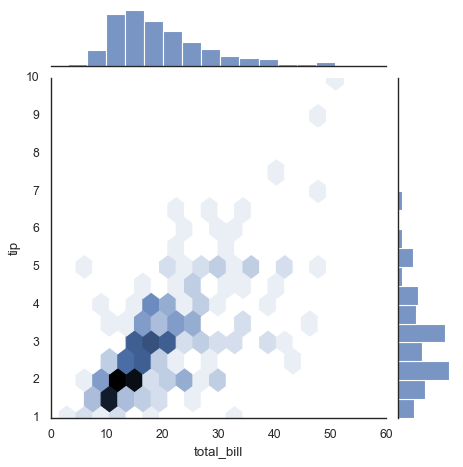

In [ ]:
# 使用 jointplot 创建 hexbin 图
with sns.axes_style('white'): 
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')

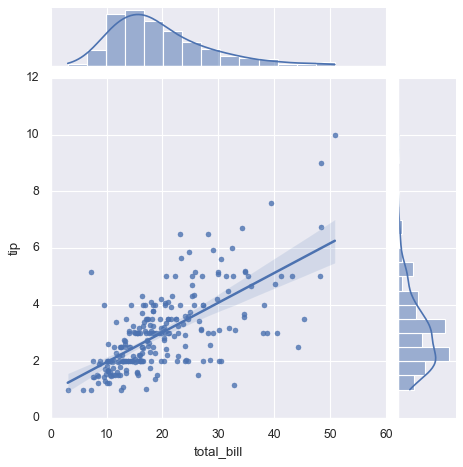

In [ ]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg'); # 带回归拟合

## 6. 条形图: 每个分类统计

In [ ]:
planets = sns.load_dataset('planets') 
planets.head() 

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


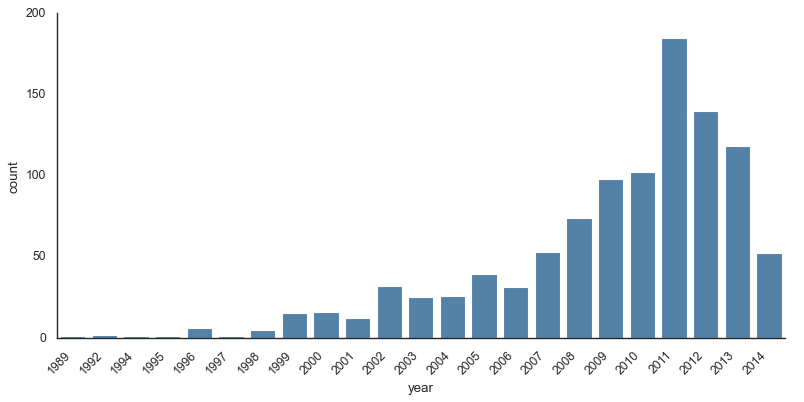

In [ ]:
# 使用 catplot 创建计数图
with sns.axes_style('white'): 
    g = sns.catplot(x="year", data=planets, aspect=2,  #aspect控制宽度
                    kind="count", color='steelblue')
    # 设置 x 轴标签的步长
    g.set_xticklabels(rotation=45, ha="right")

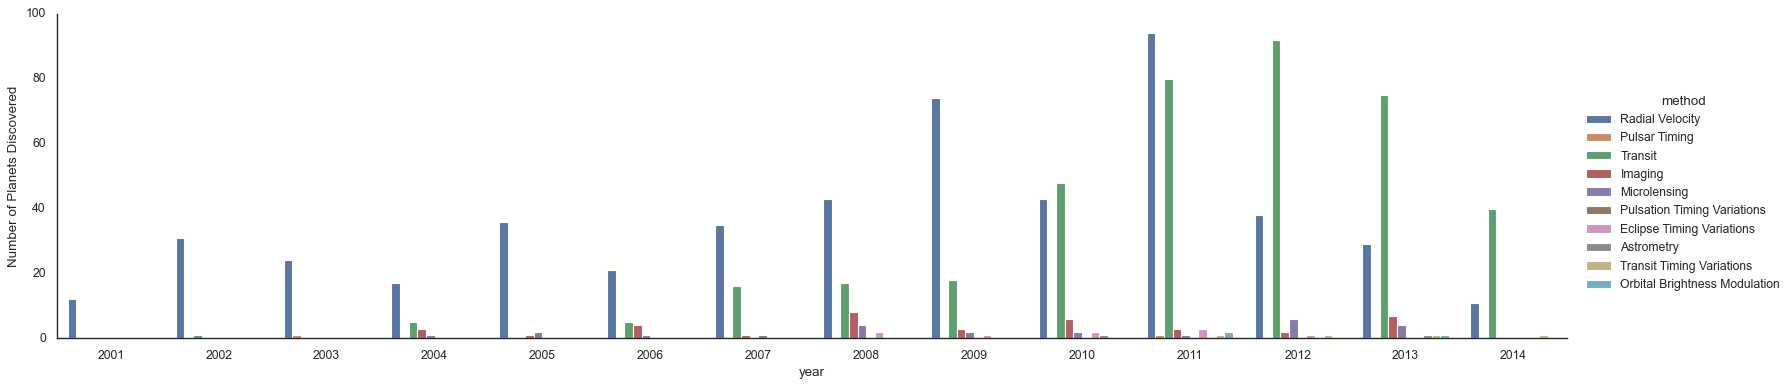

In [ ]:
# 使用 catplot 创建计数图，根据method字段着色
with sns.axes_style('white'): 
    g = sns.catplot(x="year", data=planets, aspect=4.0, kind='count', 
                    hue='method', order=range(2001, 2015)) # 指定年份

    # 设置 y 轴标签
    g.set_ylabels('Number of Planets Discovered')


## 7. 热图

可以绘制相关系数矩阵

<Axes: >

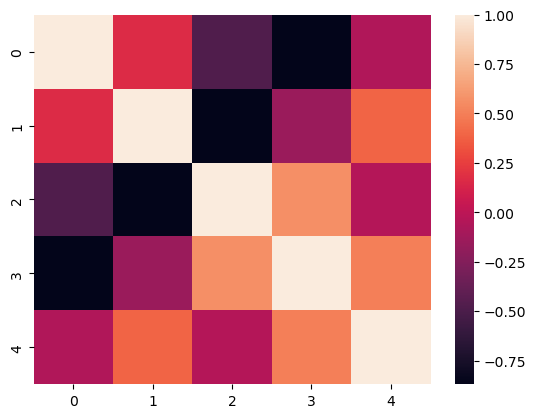

In [5]:
mat = np.random.rand(5, 5)
corrs = np.corrcoef(mat)
sns.heatmap(corrs)

<Axes: >

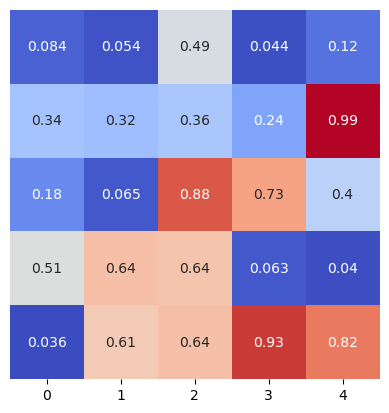

In [2]:
# 生成 5x5 矩阵
mat = np.random.rand(5, 5)

# 绘制热图
sns.heatmap(mat, 
            square=True, 
            annot=True, 
            cbar=False,
            cmap="coolwarm",
            yticklabels = False
           ) # 正方形，显示数字，不显示colorbar

## 7. 等高线

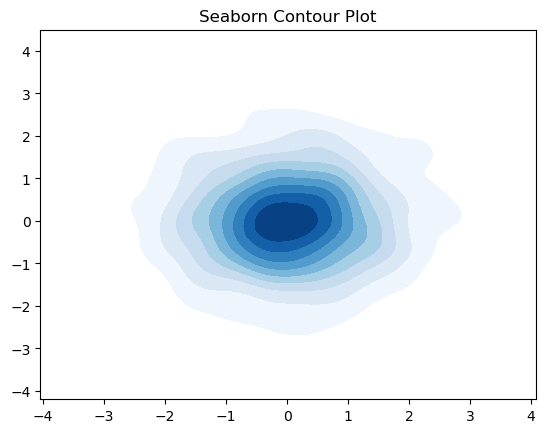

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 生成数据
x = np.random.normal(size=1000)
y = np.random.normal(size=1000)

# 使用 seaborn 绘制等高线
sns.kdeplot(x=x, y=y, cmap='Blues', fill=True, thresh=0.05)
plt.title('Seaborn Contour Plot')
plt.show()


## stripplot 条带/ 分类散点图

In [5]:
tips = sns.load_dataset("tips")

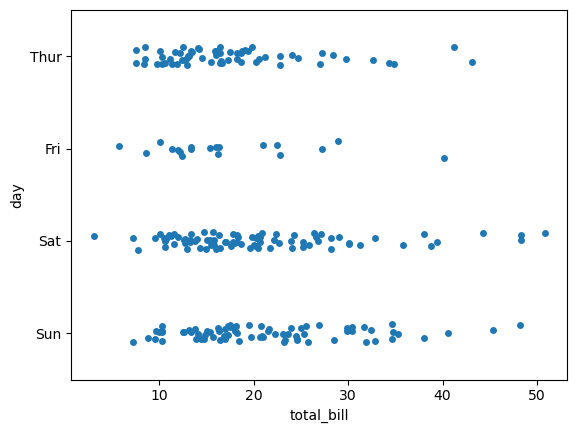

In [6]:
ax = sns.stripplot(data=tips, x="total_bill", y="day")

## 8. lineplot 折线图

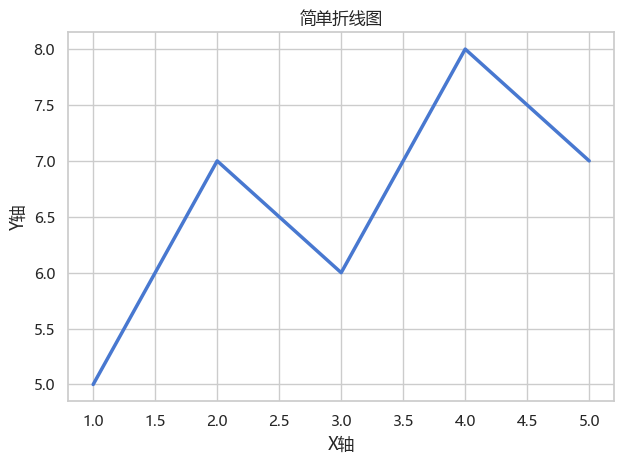

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 示例数据
data = {
    'x': [1, 2, 3, 4, 5],
    'y': [5, 7, 6, 8, 7]
}

# 画折线图
sns.lineplot(x=data['x'], y=data['y'])

plt.title('简单折线图')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.tight_layout()

## KdePlot 核密度估计
-  Kernel Density Estimate
-  平滑了样本直方图
-  支持单变量，双变量
   -  单变量就是线， 山丘
   -  双变量就是等高线， 圈越小越密集，概率越大

<Axes: xlabel='waiting', ylabel='duration'>

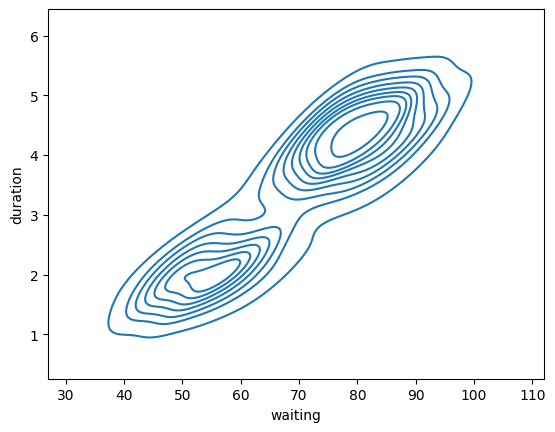

In [2]:
geyser = sns.load_dataset("geyser")
sns.kdeplot(data=geyser, x="waiting", y="duration")

<Axes: xlabel='waiting', ylabel='duration'>

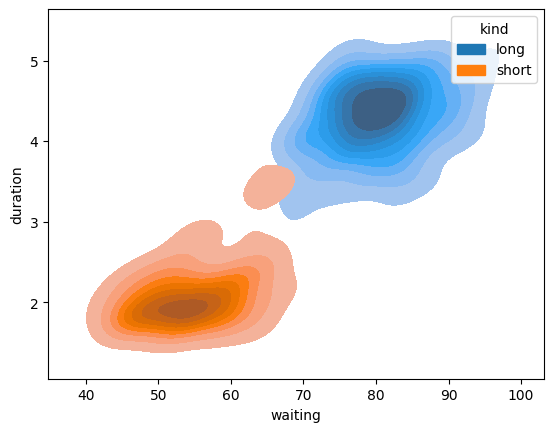

In [3]:
sns.kdeplot(
    data=geyser, x="waiting", y="duration", hue="kind", fill=True,
)


注意的是如果 标签hue数量差别大，那么会导致数量少的特征不明显。
- 这往往不符合我们的本意


In [7]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='Density'>

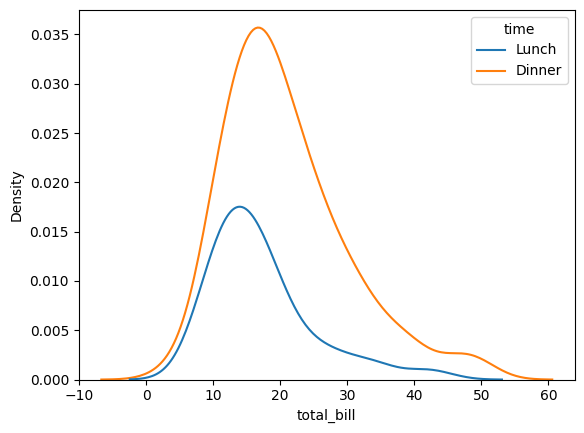

In [8]:
sns.kdeplot(
    data = tips,
    x = 'total_bill',
    hue = 'time'
)

<Axes: xlabel='total_bill', ylabel='Density'>

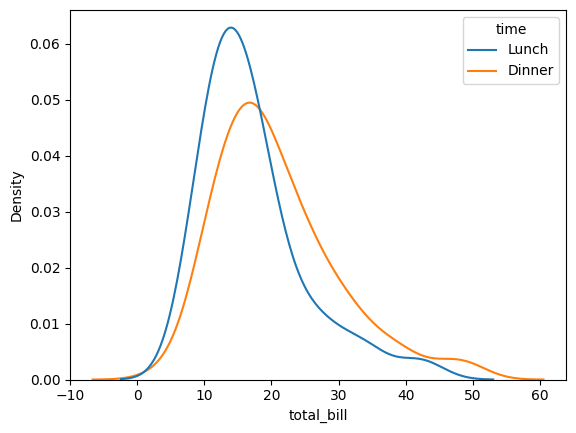

In [9]:
sns.kdeplot(
    data = tips,
    x = 'total_bill',
    hue = 'time',
    common_norm = False
)

## barplot
分类的频率图, 显示误差。 看不到计数

In [11]:
flights = sns.load_dataset(name='flights')

In [12]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


<Axes: xlabel='passengers', ylabel='year'>

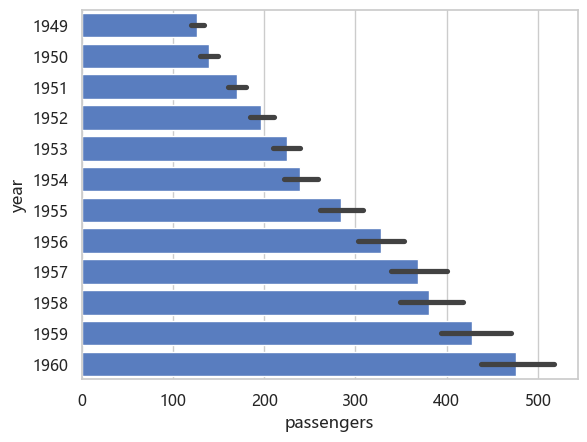

In [15]:
sns.barplot(flights, x="passengers", y="year", orient="y")

## pointplot 点图
将每组数据转为一个点：均值及误差

In [6]:
penguins = sns.load_dataset(name='penguins')

In [8]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<Axes: xlabel='species', ylabel='body_mass_g'>

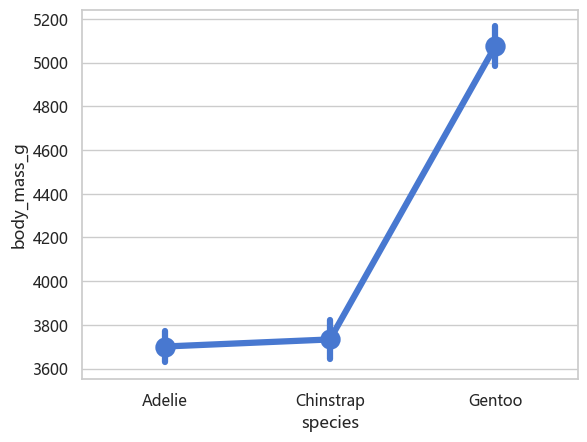

In [10]:
sns.pointplot(data=penguins, x="species", y="body_mass_g")

<Axes: xlabel='island', ylabel='body_mass_g'>

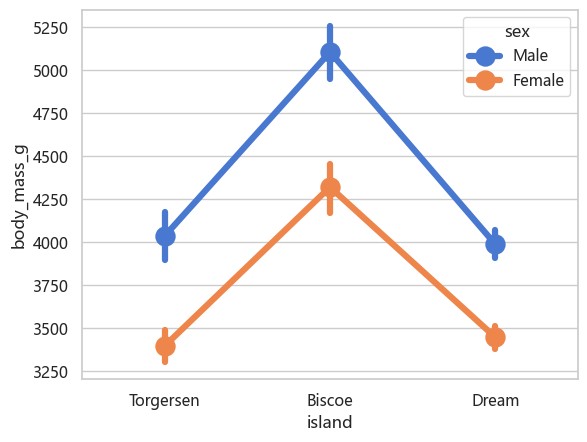

In [7]:
sns.pointplot(data=penguins, x="island", y="body_mass_g", hue="sex")

## countplot 计数图

In [1]:
sns.countplot(titanic, x="class", hue="survived", stat="percent")

NameError: name 'sns' is not defined

## Pairgrid 成对关系网格
- 搭建了网格框架，需要调用map自行塞入
- map传递的是双变量函数。`func(x,y)`

In [2]:
penguins = sns.load_dataset('penguins')

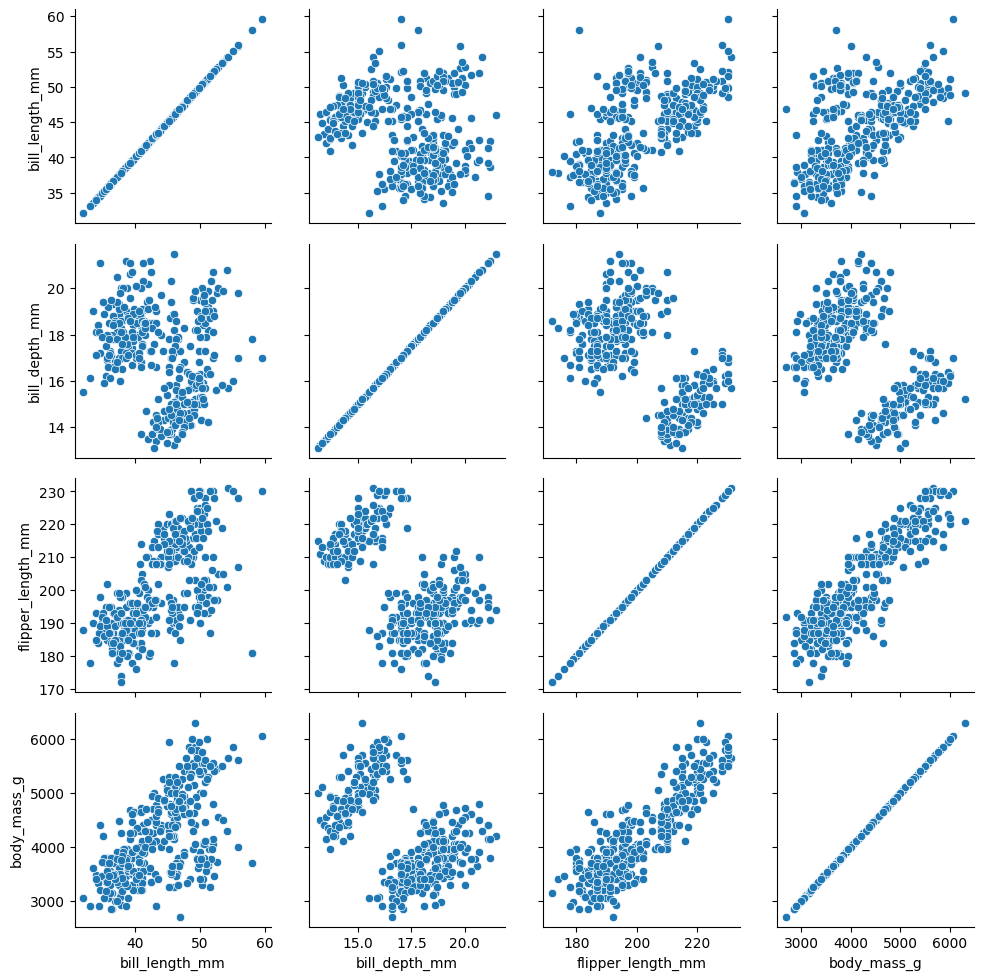

In [3]:
g = sns.PairGrid(penguins)
g.map(sns.scatterplot)

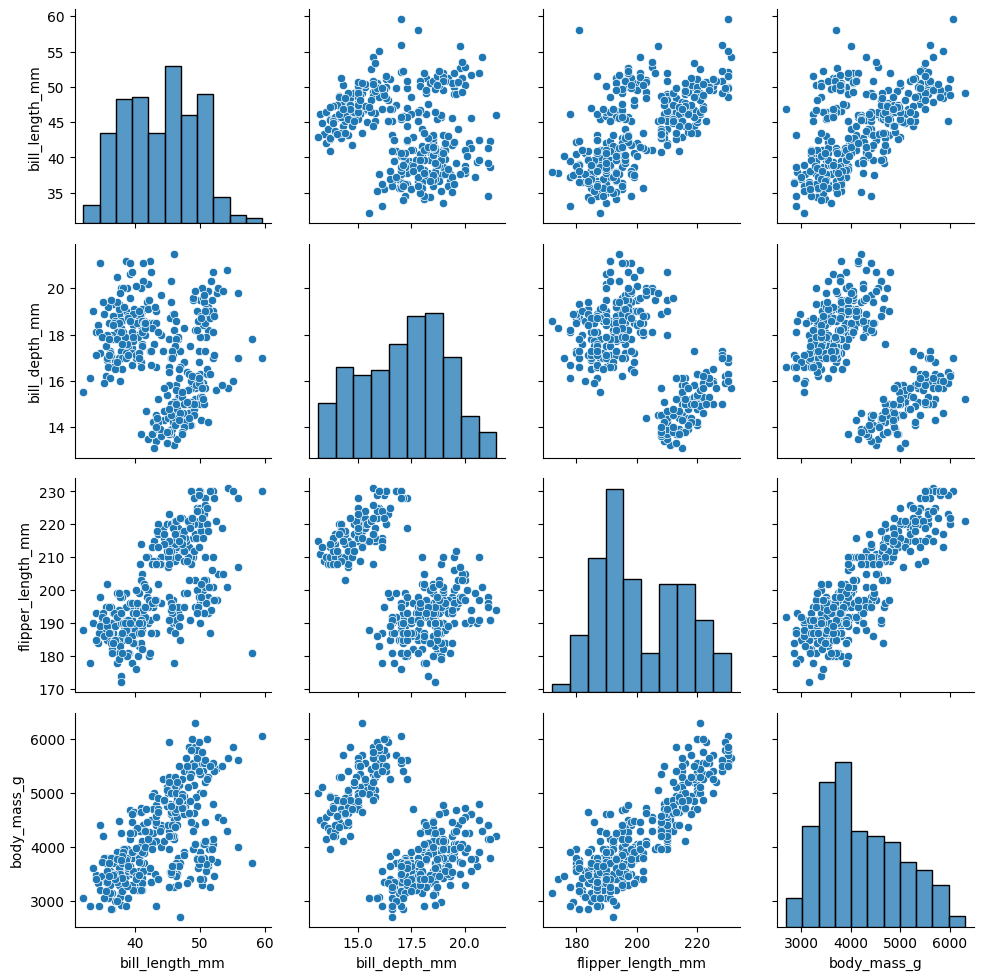

In [4]:
g = sns.PairGrid(penguins)
g.map_diag(sns.histplot) # 对角线
g.map_offdiag(sns.scatterplot) # 非对角线

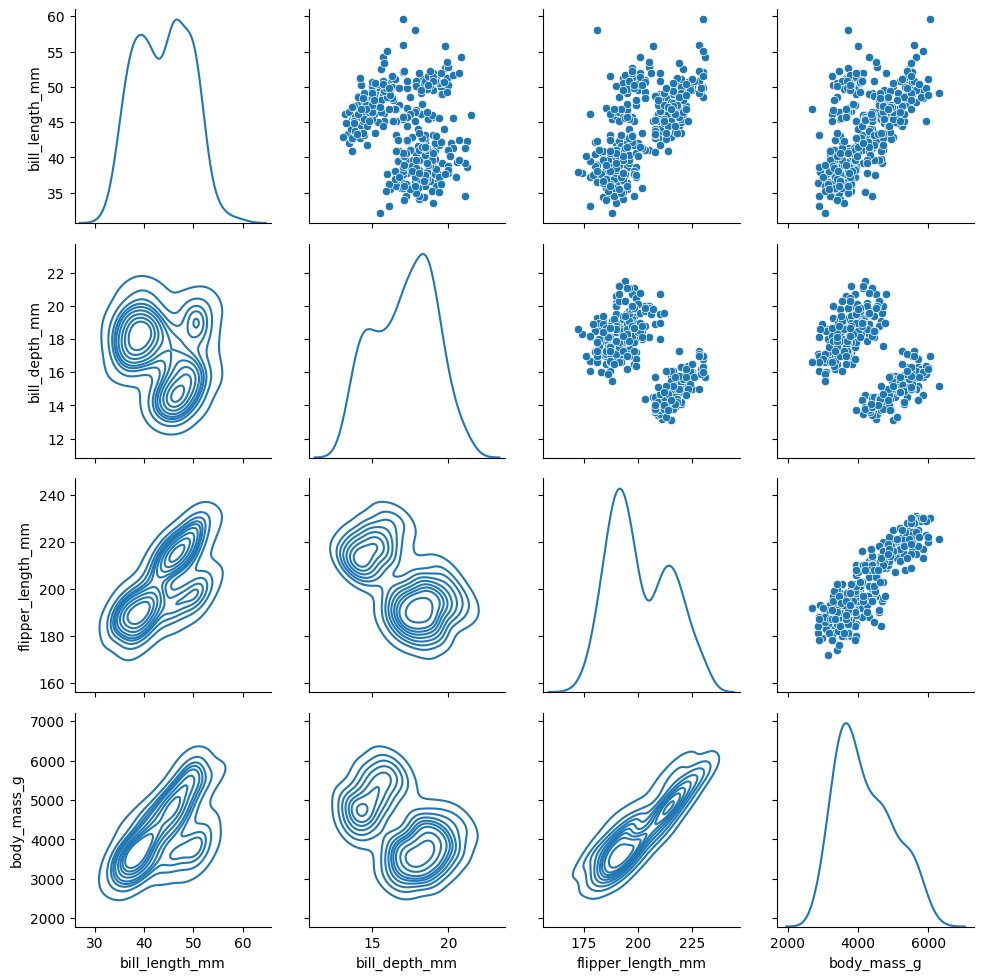

In [5]:
g = sns.PairGrid(penguins, diag_sharey=False)
g.map_upper(sns.scatterplot) # 散点
g.map_lower(sns.kdeplot) # 分布
g.map_diag(sns.kdeplot) # 分布

自定义函数
- `func(x,y, **kwargs)`

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [8]:
import numpy as np
import matplotlib.pyplot as plt
def plot_crr(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca() # 获取当前坐标轴
    ax.annotate(f"r = {r:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes, 
                ha='center', fontsize=12, fontweight='bold')

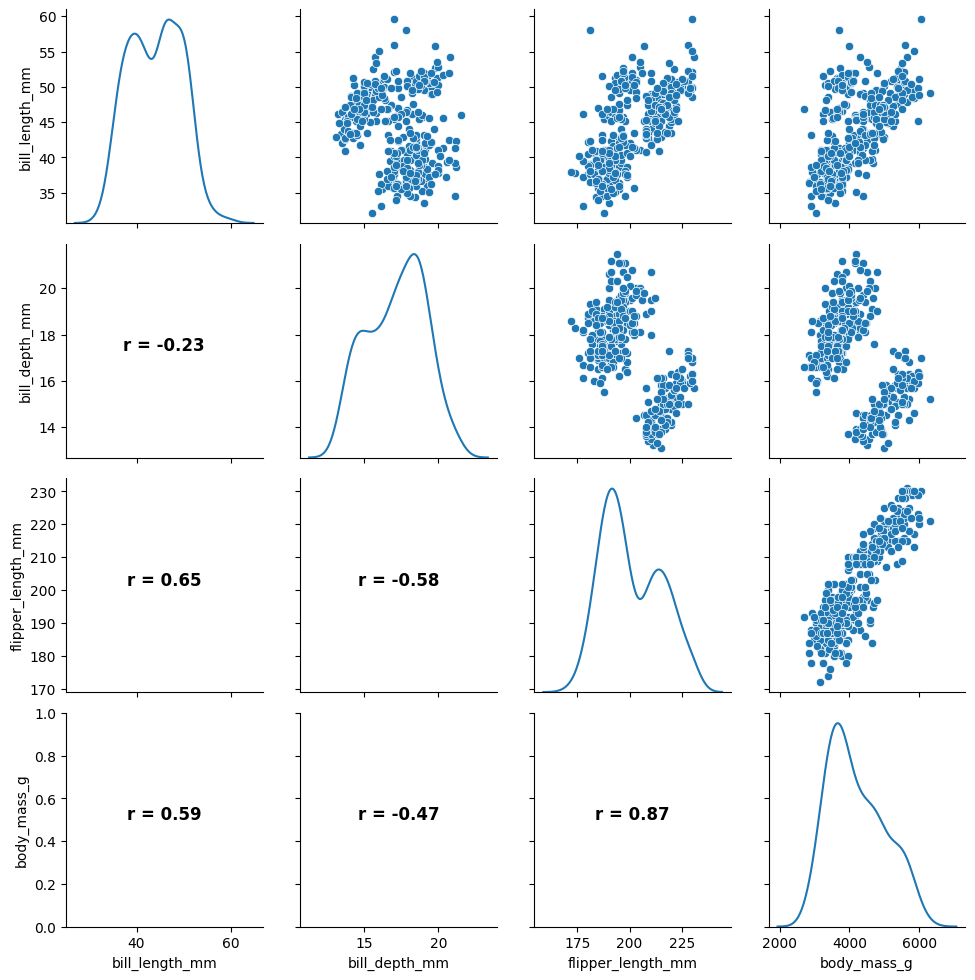

In [11]:
penguins = penguins.dropna()
g = sns.PairGrid(penguins, diag_sharey=False)
g.map_upper(sns.scatterplot) # 散点
g.map_lower(plot_crr) # 相关系数
g.map_diag(sns.kdeplot) # 分布

##　案例：探索马拉松比赛成绩数据

In [ ]:
data = pd.read_csv('marathon-data.csv') 
data.head() 

,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


In [ ]:
data.dtypes

age        int64
gender    object
split     object
final     object
dtype: object

默认情况下， 时间都会转为字符串对象，我们需要转换位时间类型

In [ ]:
def convert_time(s):
    # 分割并转换时、分、秒为整数
    h, m, s = map(int, s.split(':'))  
    # 将时分秒转换为timedelta格式
    return pd.to_timedelta(f"{h}h {m}m {s}s")
data = pd.read_csv('marathon-data.csv', converters={'split':convert_time, 'final':convert_time})  # 导入时，就传入转换函数
data.head() 

,age,gender,split,final
0,33,M,0 days 01:05:38,0 days 02:08:51
1,32,M,0 days 01:06:26,0 days 02:09:28
2,31,M,0 days 01:06:49,0 days 02:10:42
3,38,M,0 days 01:06:16,0 days 02:13:45
4,31,M,0 days 01:06:32,0 days 02:13:59


In [ ]:
data.dtypes

age                 int64
gender             object
split     timedelta64[ns]
final     timedelta64[ns]
dtype: object

In [ ]:
data['split_sec'] = data['split'].astype(int) / 1E9 
data['final_sec'] = data['final'].astype(int) / 1E9 
data.head() 

,age,gender,split,final,split_sec,final_sec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0


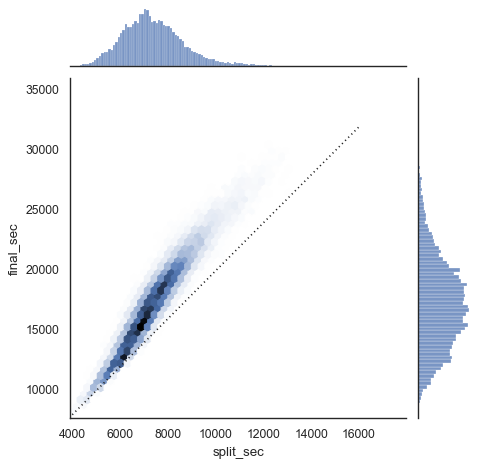

In [ ]:
 with sns.axes_style('white'):
    g = sns.jointplot(x="split_sec", y="final_sec", data=data, kind='hex')
    g.ax_joint.plot(np.linspace(4000, 16000), np.linspace(8000, 32000), ':k') # 添加一条虚线： 

虚线表示这个人上半程时间和下半程时间一样。 但是显然，后半程更加耗时，越跑越慢。

现在衡量后半程加速的程度，小于0表示时后半程加速选手

In [ ]:
data['split_frac'] = 1 - 2 * data['split_sec'] / data['final_sec'] 
data.head() 

,age,gender,split,final,split_sec,final_sec,split_frac
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842


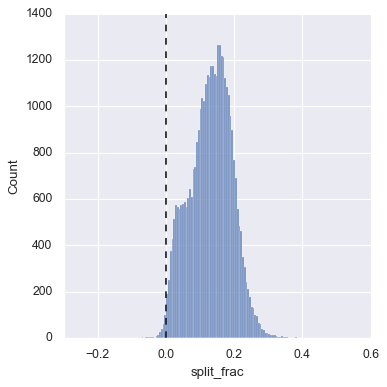

In [ ]:
sns.displot(data['split_frac'], kde=False); 
plt.axvline(0, color="k", linestyle="--");

In [ ]:
sum(data.split_frac < 0) 

251

可以看到，4万名仅仅有250名时后半程加速选手。

那探究这与其他变量是否有相关性

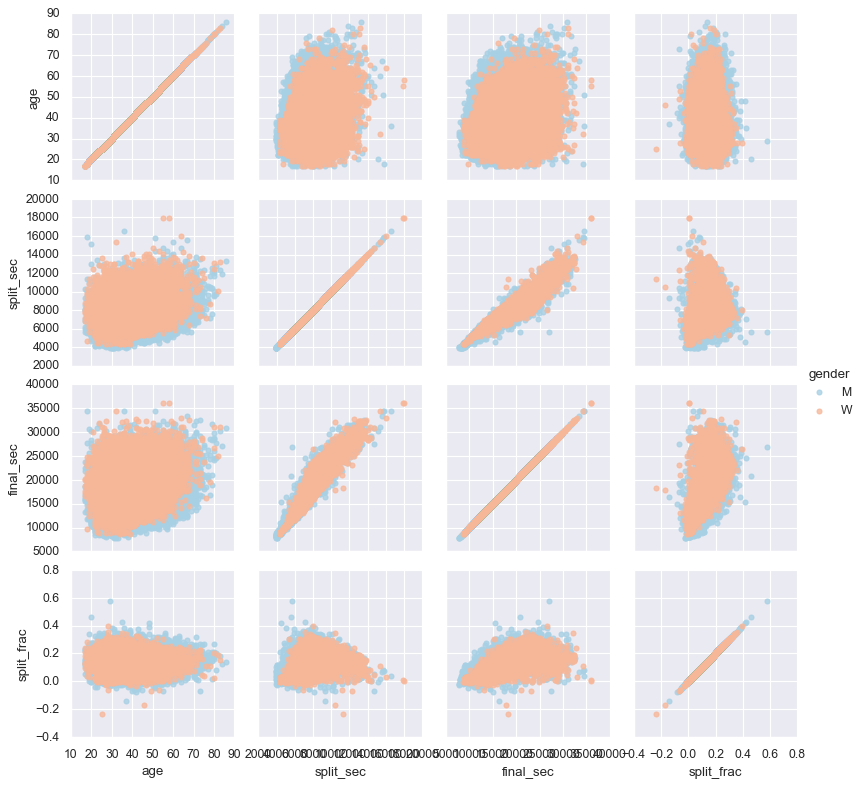

In [ ]:
g = sns.PairGrid(data, vars=['age', 'split_sec', 'final_sec', 'split_frac'], 
                 hue='gender', palette='RdBu_r')  # pairplot自由版
g.map(plt.scatter, alpha=0.8) 
g.add_legend();

没看出什么相关性

对比男女选手差异：

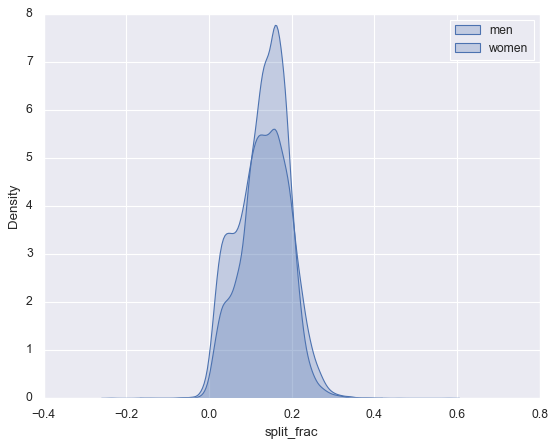

In [ ]:
sns.kdeplot(data.split_frac[data.gender=='M'], label='men', fill=True) 
sns.kdeplot(data.split_frac[data.gender=='W'], label='women', fill=True) 
plt.legend()

男女的后半程加速系数 几乎都是双峰分布

分开来看

<Axes: xlabel='gender', ylabel='split_frac'>

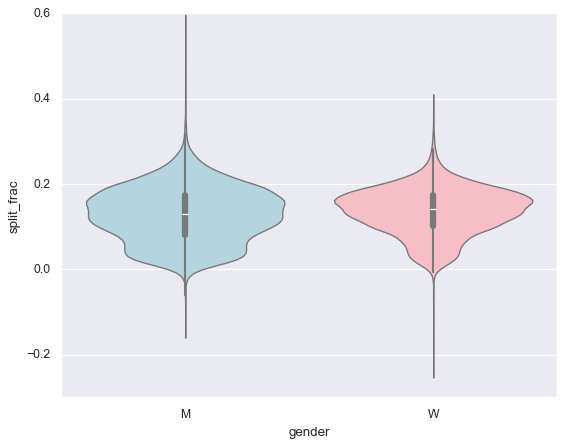

In [ ]:
sns.violinplot(x="gender", y="split_frac", hue="gender", data=data, 
               palette=["lightblue", "lightpink"], legend=False)

通过年龄段再看看

In [ ]:
data['age_dec'] = data.age.map(lambda age: 10 * (age // 10)) 
data.head() 

,age,gender,split,final,split_sec,final_sec,split_frac,age_dec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756,30
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262,30
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443,30
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097,30
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842,30


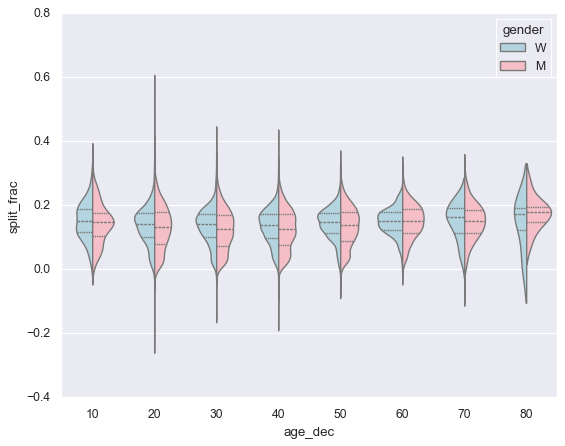

In [ ]:
men = (data.gender == 'M') 
women = (data.gender == 'W') 

with sns.axes_style(style=None): 
    sns.violinplot(x="age_dec", y="split_frac", hue="gender", data=data, split=True, inner="quartile", 
                   palette=["lightblue", "lightpink"], legend=True)

可以看到 20-50岁，男性选手 后半程加速系数的分布 更加松散。 80以上的女选手发挥比80以上男选手发挥好得多

In [ ]:
(data.age > 80).sum() 

np.int64(7)

这是因为80以上样本太少了

观察是哪些选手的 后半程加速系数 小于0

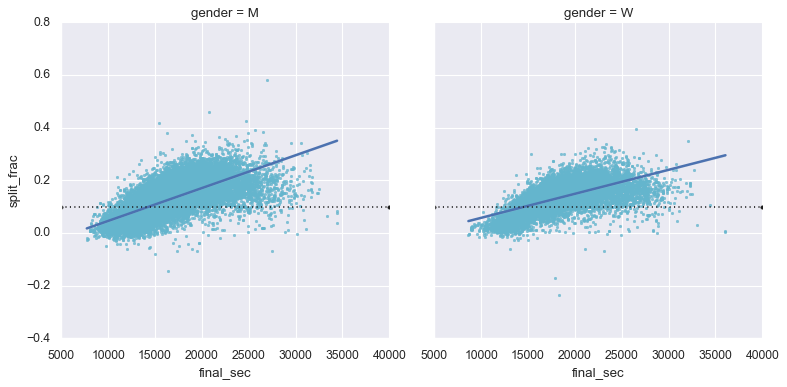

In [ ]:
# Lmplot绘制散点图，并拟合直线。  col表示根据gender划分两个子图，
g = sns.lmplot(x='final_sec',y= 'split_frac', col='gender', data=data, 
                       markers=".", scatter_kws=dict(color='c')) 
g.map(plt.axhline, y=0.1, color="k", ls=":");

发现后半程加速选手的成绩都在15000秒内。

https://seaborn.pydata.org/generated/seaborn.heatmap.html